# Name : Kewal Thacker
# Date : 07/08/2025
# Reg No. : 230968126
# Deep Learning Lab 3 (Batch A1)

# Demo 

## 1) Import the required libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

2025-08-07 11:41:49.660412: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-07 11:41:49.683941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754547109.712360  345082 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754547109.721618  345082 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754547109.743019  345082 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 2) Load the built-in MNIST Dataset from Keras

In [2]:
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

### 2.1) Understand the dataset

X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
Minimum pixel value:  0
Maximum pixel value:  255


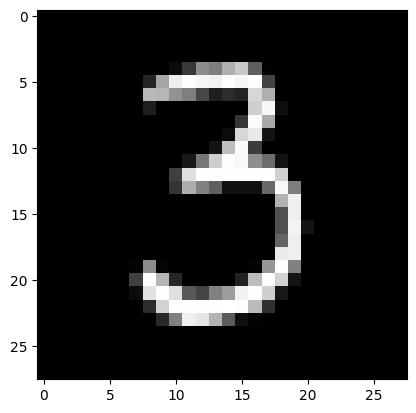

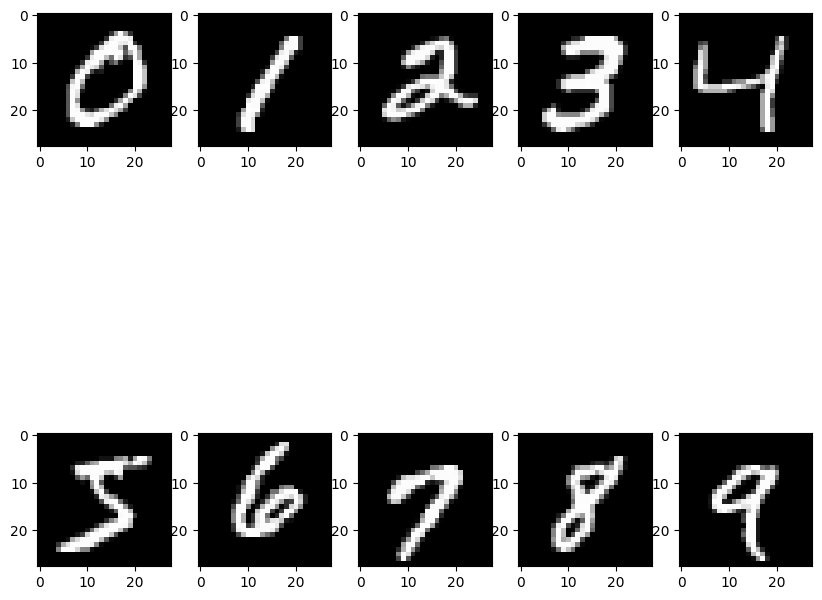

In [3]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Minimum pixel value: ", np.min(X_train[0]))
print("Maximum pixel value: ", np.max(X_train[0]))

plt.imshow(X_train[50], cmap = "gray")

(X,id) = np.unique(y_train, return_index = True)
plt.figure(figsize = (10,10))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[id[i]], cmap = "gray")

## 3) Pre-process the dataset

In [4]:
# perform normalization
X_train = X_train/255.0
X_test = X_test/255.0

## 4) Define the CNN Model

In [5]:
model_cnn = tf.keras.Sequential()
model_cnn.add(tf.keras.Input(shape = (28,28,1)))
model_cnn.add(tf.keras.layers.Conv2D(128, kernel_size = (3,3), activation = "relu", padding = "valid"))
model_cnn.add(tf.keras.layers.MaxPooling2D(pool_size = (2,2)))
model_cnn.add(tf.keras.layers.Conv2D(256, kernel_size = (3,3), activation = "relu", padding = "valid"))
model_cnn.add(tf.keras.layers.MaxPooling2D(pool_size = (2,2)))
model_cnn.add(tf.keras.layers.Flatten())
model_cnn.add(tf.keras.layers.Dense(100, activation = "relu"))
model_cnn.add(tf.keras.layers.Dense(10, activation = "softmax"))

I0000 00:00:1754547115.819816  345082 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10177 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
X_train.shape[0]

60000

In [7]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       640,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 937,558 (3.58 MB)

 Trainable params: 937,558 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

## 5) Compile the CNN Model 

In [8]:
opt2 = tf.keras.optimizers.Adam(learning_rate = 0.01)
model_cnn.compile(loss = "sparse_categorical_crossentropy", optimizer = opt2, metrics = ["accuracy"])

## 6) Fit the model (training)

In [9]:
batch_size = 32
epochs = 15
res_cnn = model_cnn.fit(X_train, y_train, batch_size = batch_size, epochs = epochs, validation_split = 0.1)

Epoch 1/15


I0000 00:00:1754547118.757390  345213 service.cc:152] XLA service 0x7fdb5800bcc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754547118.757433  345213 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-08-07 11:41:58.798975: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754547119.064097  345213 cuda_dnn.cc:529] Loaded cuDNN version 91100


  29/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1621 - loss: 3.3809

I0000 00:00:1754547122.890036  345213 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8837 - loss: 0.3984 - val_accuracy: 0.9795 - val_loss: 0.0643
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9758 - loss: 0.0808 - val_accuracy: 0.9837 - val_loss: 0.0589
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9799 - loss: 0.0679 - val_accuracy: 0.9808 - val_loss: 0.0720
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9797 - loss: 0.0691 - val_accuracy: 0.9788 - val_loss: 0.1034
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9828 - loss: 0.0636 - val_accuracy: 0.9790 - val_loss: 0.0823
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9842 - loss: 0.0572 - val_accuracy: 0.9857 - val_loss: 0.0670
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9846 - loss: 0.0560 - val_accuracy: 0.9830 - val_loss: 0.0793
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9834 - loss: 0.0598 - val

Text(0.5, 1.0, 'Accuracy over epochs')

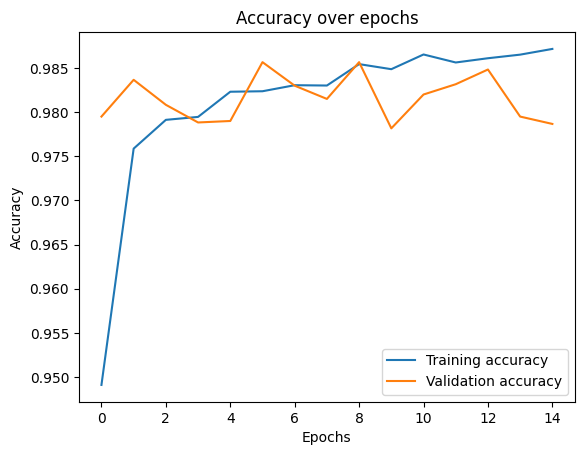

In [10]:
plt.plot(res_cnn.history['accuracy'], label = "Training accuracy")
plt.plot(res_cnn.history['val_accuracy'], label = "Validation accuracy")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy over epochs")

Text(0.5, 1.0, 'Loss over epochs')

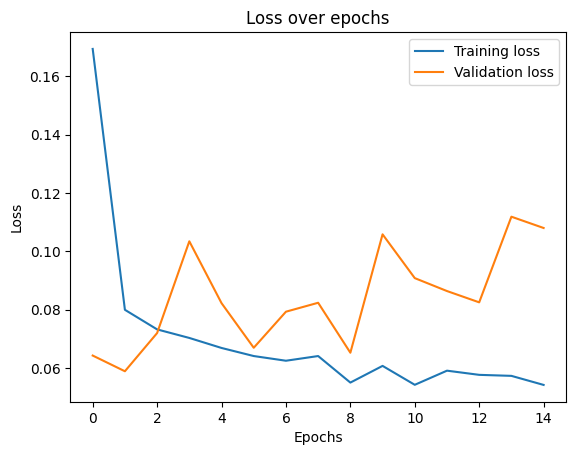

In [11]:
plt.plot(res_cnn.history['loss'], label = "Training loss")
plt.plot(res_cnn.history['val_loss'], label = "Validation loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over epochs")

## 7) Evaluate

In [12]:
loss, accuracy = model_cnn.evaluate(X_test, y_test)
print("Accuracy:", accuracy)
print("Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9704 - loss: 0.1362
Accuracy: 0.9757999777793884
Loss: 0.10874910652637482


In [13]:
y_pred_probs = model_cnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis = 1) 
clf = classification_report(y_test, y_pred)
print(clf)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.99      0.98      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.94      0.99      0.96       974
           9       0.98      0.94      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Exercise 1 - Dataset A : Fashion MNIST Dataset

## 1) Import necessary libraries

In [14]:
from tensorflow.keras.datasets import fashion_mnist, cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## 2) Load the dataset

In [15]:
(x_train_fm, y_train_fm), (x_test_fm, y_test_fm) = fashion_mnist.load_data()

### 2.1) Understand the dataset

Fashion MNIST Number of Classes: 10
Fashion MNIST Image Shape: (28, 28, 1)


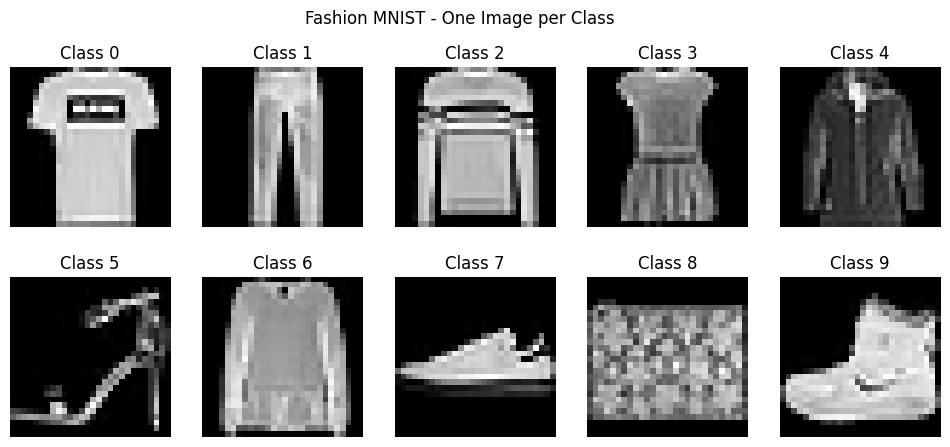

In [18]:
num_classes_fm = len(np.unique(y_train_fm))
print(f"Fashion MNIST Number of Classes: {num_classes_fm}")

x_train_fm = x_train_fm[..., np.newaxis]
x_test_fm = x_test_fm[..., np.newaxis]
img_shape_fm = x_train_fm.shape[1:] 

print(f"Fashion MNIST Image Shape: {img_shape_fm}")

# Display one image from each class
plt.figure(figsize=(12, 5))
for i in range(num_classes_fm):
    idx = np.where(y_train_fm == i)[0][0]  
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train_fm[idx].squeeze(), cmap='gray')
    plt.title(f"Class {i}")
    plt.axis('off')
plt.suptitle("Fashion MNIST - One Image per Class")
plt.show()

## 3) Preprocess the Dataset

In [19]:
# Normalize pixel values to [0, 1]
x_train_fm = x_train_fm.astype('float32') / 255.0
x_test_fm = x_test_fm.astype('float32') / 255.0

# One-hot encode labels
y_train_fm_cat = to_categorical(y_train_fm, num_classes_fm)
y_test_fm_cat = to_categorical(y_test_fm, num_classes_fm)

## 4) Define the FCNN Model

In [20]:
# Build FCNN model for Fashion MNIST
model_fcnn_fm = Sequential()
model_fcnn_fm.add(Flatten(input_shape=img_shape_fm))
model_fcnn_fm.add(Dense(256, activation='relu'))
model_fcnn_fm.add(Dense(128, activation='relu'))
model_fcnn_fm.add(Dense(num_classes_fm, activation='softmax'))

model_fcnn_fm.summary()

/home/student/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5) Compile the FCNN Model

In [21]:
model_fcnn_fm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 6) Train the FCNN Model

In [22]:
history_fcnn_fm = model_fcnn_fm.fit(
    x_train_fm, y_train_fm_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=2
)

Epoch 1/20


2025-08-07 11:48:26.981027: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_162', 8 bytes spill stores, 8 bytes spill loads

2025-08-07 11:48:27.076439: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_162', 104 bytes spill stores, 104 bytes spill loads

2025-08-07 11:48:27.910141: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_312', 80 bytes spill stores, 80 bytes spill loads

2025-08-07 11:48:28.906857: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 4 bytes spill stores, 4 bytes spill loads

2025-08-07 11:48:30.102952: I external/local_x

844/844 - 20s - 23ms/step - accuracy: 0.8204 - loss: 0.5037 - val_accuracy: 0.8552 - val_loss: 0.4054
Epoch 2/20
844/844 - 4s - 4ms/step - accuracy: 0.8676 - loss: 0.3649 - val_accuracy: 0.8637 - val_loss: 0.3739
Epoch 3/20
844/844 - 4s - 4ms/step - accuracy: 0.8784 - loss: 0.3273 - val_accuracy: 0.8702 - val_loss: 0.3615
Epoch 4/20
844/844 - 4s - 4ms/step - accuracy: 0.8884 - loss: 0.3021 - val_accuracy: 0.8717 - val_loss: 0.3475
Epoch 5/20
844/844 - 4s - 4ms/step - accuracy: 0.8934 - loss: 0.2843 - val_accuracy: 0.8725 - val_loss: 0.3412
Epoch 6/20
844/844 - 4s - 4ms/step - accuracy: 0.8987 - loss: 0.2716 - val_accuracy: 0.8735 - val_loss: 0.3473
Epoch 7/20
844/844 - 4s - 4ms/step - accuracy: 0.9022 - loss: 0.2580 - val_accuracy: 0.8798 - val_loss: 0.3353
Epoch 8/20
844/844 - 4s - 4ms/step - accuracy: 0.9076 - loss: 0.2457 - val_accuracy: 0.8740 - val_loss: 0.3585
Epoch 9/20
844/844 - 4s - 4ms/step - accuracy: 0.9124 - loss: 0.2327 - val_accuracy: 0.8892 - val_loss: 0.3160
Epoch 10/2

## 7) Evaluate the FCNN Model

2025-08-07 11:49:53.878849: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_69', 4 bytes spill stores, 4 bytes spill loads



Fashion MNIST FCNN Test Accuracy: 0.8967


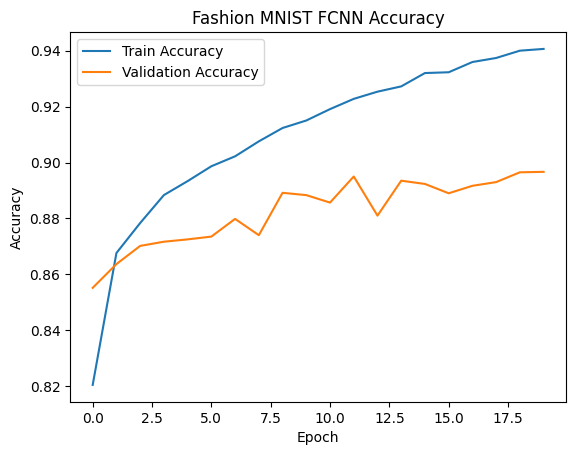

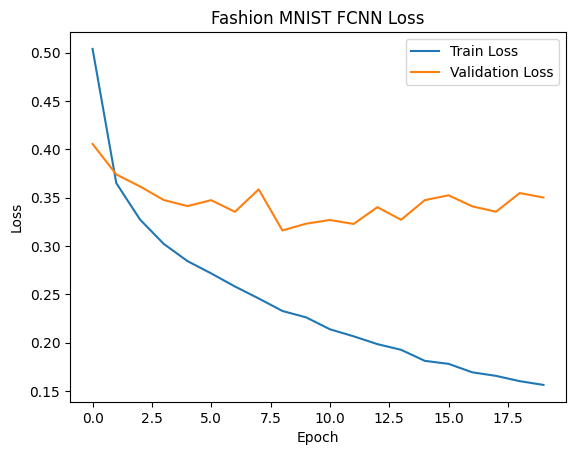

In [23]:
loss_fcnn_fm, acc_fcnn_fm = model_fcnn_fm.evaluate(x_test_fm, y_test_fm_cat, verbose=0)
print(f"Fashion MNIST FCNN Test Accuracy: {acc_fcnn_fm:.4f}")

# Plot accuracy curves
plt.plot(history_fcnn_fm.history['accuracy'], label='Train Accuracy')
plt.plot(history_fcnn_fm.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fashion MNIST FCNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss curves
plt.plot(history_fcnn_fm.history['loss'], label='Train Loss')
plt.plot(history_fcnn_fm.history['val_loss'], label='Validation Loss')
plt.title('Fashion MNIST FCNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [24]:
# Classification report
y_pred_probs = model_fcnn_fm.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis = 1) 
clf = classification_report(y_test, y_pred)
print(clf)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

           0       0.01      0.02      0.01       980
           1       0.87      0.40      0.55      1135
           2       0.13      0.01      0.02      1032
           3       0.28      0.19      0.23      1010
           4       0.20      0.12      0.15       982
           5       0.14      0.59      0.23       892
           6       0.03      0.02      0.02       958
           7       0.06      0.05      0.05      1028
           8       0.05      0.03      0.04       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.14     10000
   macro avg       0.18      0.14      0.13     10000
weighted avg       0.19      0.14      0.14     10000



## 8) Define first CNN Model

In [25]:
model_cnn1_fm = Sequential()
model_cnn1_fm.add(Conv2D(32, kernel_size=(5,5), strides=1, padding='valid', activation='relu', input_shape=img_shape_fm))
model_cnn1_fm.add(MaxPooling2D(pool_size=(2,2), strides=2))
model_cnn1_fm.add(Flatten())
model_cnn1_fm.add(Dense(100, activation='relu'))
model_cnn1_fm.add(Dense(num_classes_fm, activation='softmax'))

model_cnn1_fm.summary()

/home/student/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │       460,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,742 (1.77 MB)

 Trainable params: 462,742 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

## 9) Compile the first CNN Model

In [26]:
model_cnn1_fm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 10) Train the first CNN Model

In [28]:
history_cnn1_fm = model_cnn1_fm.fit(
    x_train_fm, y_train_fm_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=2
)

Epoch 1/20
844/844 - 13s - 15ms/step - accuracy: 0.8385 - loss: 0.4579 - val_accuracy: 0.8723 - val_loss: 0.3401
Epoch 2/20
844/844 - 4s - 4ms/step - accuracy: 0.8909 - loss: 0.3054 - val_accuracy: 0.8858 - val_loss: 0.3197
Epoch 3/20
844/844 - 4s - 4ms/step - accuracy: 0.9052 - loss: 0.2625 - val_accuracy: 0.8998 - val_loss: 0.2756
Epoch 4/20
844/844 - 4s - 4ms/step - accuracy: 0.9159 - loss: 0.2311 - val_accuracy: 0.9042 - val_loss: 0.2632
Epoch 5/20
844/844 - 4s - 4ms/step - accuracy: 0.9239 - loss: 0.2068 - val_accuracy: 0.9020 - val_loss: 0.2720
Epoch 6/20
844/844 - 4s - 4ms/step - accuracy: 0.9326 - loss: 0.1850 - val_accuracy: 0.9048 - val_loss: 0.2634
Epoch 7/20
844/844 - 4s - 4ms/step - accuracy: 0.9391 - loss: 0.1648 - val_accuracy: 0.9102 - val_loss: 0.2582
Epoch 8/20
844/844 - 4s - 4ms/step - accuracy: 0.9457 - loss: 0.1476 - val_accuracy: 0.9137 - val_loss: 0.2483
Epoch 9/20
844/844 - 4s - 4ms/step - accuracy: 0.9514 - loss: 0.1323 - val_accuracy: 0.9163 - val_loss: 0.2555

## 11) Evaluate the first CNN Model

Fashion MNIST CNN-1 Test Accuracy: 0.9136


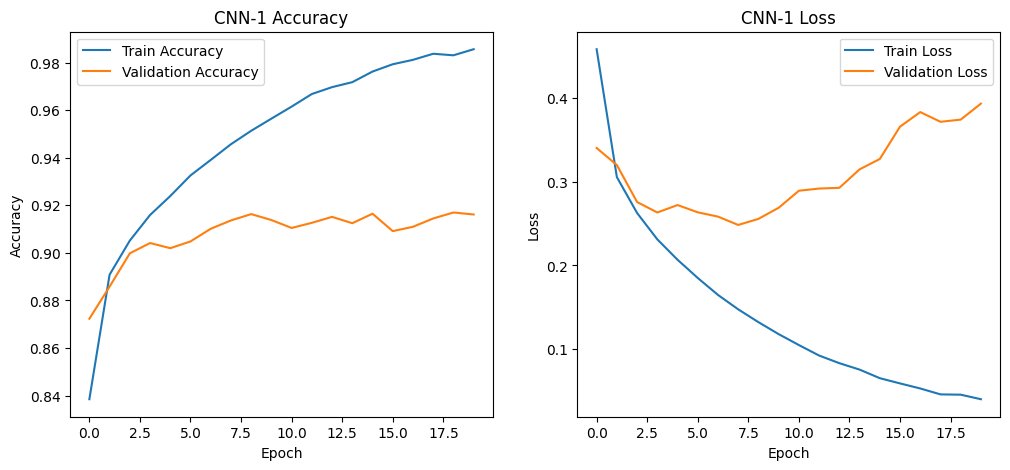

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report for CNN-1 (Fashion MNIST):
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1000
           1       0.99      0.98      0.99      1000
           2       0.86      0.86      0.86      1000
           3       0.92      0.92      0.92      1000
           4       0.84      0.88      0.86      1000
           5       0.98      0.98      0.98      1000
           6       0.80      0.72      0.76      1000
           7       0.97      0.96      0.97      1000
           8       0.98      0.98      0.98      1000
           9       0.96      0.98      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [29]:
loss_cnn1_fm, acc_cnn1_fm = model_cnn1_fm.evaluate(x_test_fm, y_test_fm_cat, verbose=0)
print(f"Fashion MNIST CNN-1 Test Accuracy: {acc_cnn1_fm:.4f}")

# Plot accuracy and loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_cnn1_fm.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn1_fm.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN-1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn1_fm.history['loss'], label='Train Loss')
plt.plot(history_cnn1_fm.history['val_loss'], label='Validation Loss')
plt.title('CNN-1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Classification report
y_pred_cnn1_fm = model_cnn1_fm.predict(x_test_fm)
y_pred_labels_cnn1_fm = np.argmax(y_pred_cnn1_fm, axis=1)
print("Classification Report for CNN-1 (Fashion MNIST):")
print(classification_report(y_test_fm, y_pred_labels_cnn1_fm))

## 12) Define the second CNN Model

In [30]:
model_cnn2_fm = Sequential()
model_cnn2_fm.add(Conv2D(32, kernel_size=(3,3), strides=1, padding='valid', activation='relu', input_shape=img_shape_fm))
model_cnn2_fm.add(Conv2D(32, kernel_size=(3,3), strides=1, padding='valid', activation='relu'))
model_cnn2_fm.add(MaxPooling2D(pool_size=(2,2), strides=2))
model_cnn2_fm.add(Flatten())
model_cnn2_fm.add(Dense(100, activation='relu'))
model_cnn2_fm.add(Dense(num_classes_fm, activation='softmax'))

model_cnn2_fm.summary()

/home/student/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │       460,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,478 (1.80 MB)

 Trainable params: 471,478 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

## 13) Compile the second CNN Model

In [32]:
model_cnn2_fm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 14) Train the second CNN Model

In [33]:
history_cnn2_fm = model_cnn2_fm.fit(
    x_train_fm, y_train_fm_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=2
)

Epoch 1/20
844/844 - 11s - 13ms/step - accuracy: 0.8515 - loss: 0.4198 - val_accuracy: 0.8897 - val_loss: 0.3031
Epoch 2/20
844/844 - 4s - 5ms/step - accuracy: 0.9034 - loss: 0.2666 - val_accuracy: 0.9073 - val_loss: 0.2458
Epoch 3/20
844/844 - 4s - 5ms/step - accuracy: 0.9211 - loss: 0.2156 - val_accuracy: 0.9148 - val_loss: 0.2318
Epoch 4/20
844/844 - 4s - 5ms/step - accuracy: 0.9330 - loss: 0.1804 - val_accuracy: 0.9133 - val_loss: 0.2416
Epoch 5/20
844/844 - 4s - 5ms/step - accuracy: 0.9454 - loss: 0.1490 - val_accuracy: 0.9158 - val_loss: 0.2309
Epoch 6/20
844/844 - 4s - 5ms/step - accuracy: 0.9536 - loss: 0.1239 - val_accuracy: 0.9222 - val_loss: 0.2387
Epoch 7/20
844/844 - 4s - 5ms/step - accuracy: 0.9627 - loss: 0.1015 - val_accuracy: 0.9213 - val_loss: 0.2636
Epoch 8/20
844/844 - 4s - 5ms/step - accuracy: 0.9707 - loss: 0.0806 - val_accuracy: 0.9187 - val_loss: 0.2790
Epoch 9/20
844/844 - 4s - 5ms/step - accuracy: 0.9773 - loss: 0.0620 - val_accuracy: 0.9207 - val_loss: 0.3004

## 15) Evaluate the second CNN Model

Fashion MNIST CNN-2 Test Accuracy: 0.9128


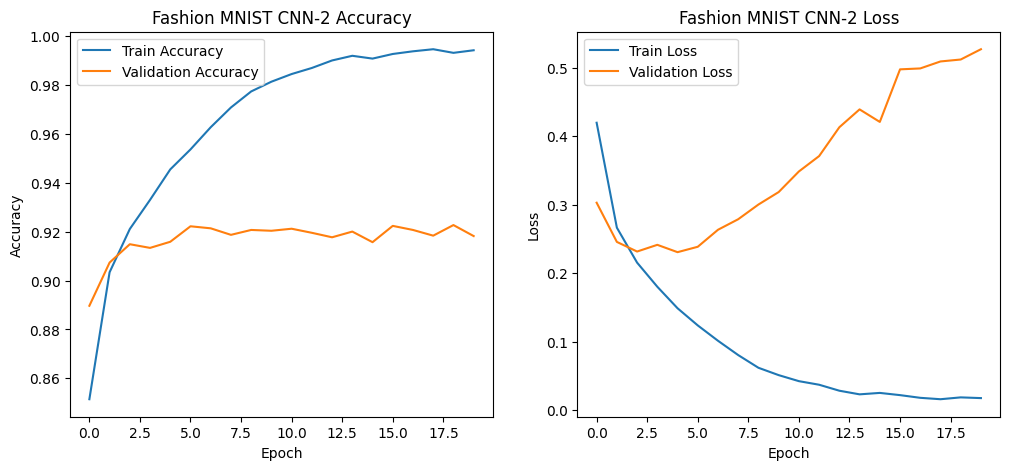

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report for CNN-2 (Fashion MNIST):
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1000
           1       0.99      0.97      0.98      1000
           2       0.86      0.87      0.87      1000
           3       0.93      0.87      0.90      1000
           4       0.87      0.88      0.88      1000
           5       0.99      0.98      0.98      1000
           6       0.75      0.76      0.75      1000
           7       0.96      0.98      0.97      1000
           8       0.96      0.98      0.97      1000
           9       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [34]:
loss_cnn2_fm, acc_cnn2_fm = model_cnn2_fm.evaluate(x_test_fm, y_test_fm_cat, verbose=0)
print(f"Fashion MNIST CNN-2 Test Accuracy: {acc_cnn2_fm:.4f}")

# Plot accuracy and loss curves for CNN-2 FM
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_cnn2_fm.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn2_fm.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fashion MNIST CNN-2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn2_fm.history['loss'], label='Train Loss')
plt.plot(history_cnn2_fm.history['val_loss'], label='Validation Loss')
plt.title('Fashion MNIST CNN-2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Classification report
y_pred_cnn2_fm = model_cnn2_fm.predict(x_test_fm)
y_pred_labels_cnn2_fm = np.argmax(y_pred_cnn2_fm, axis=1)
print("Classification Report for CNN-2 (Fashion MNIST):")
print(classification_report(y_test_fm, y_pred_labels_cnn2_fm))

# Exercise 2 - Dataset B : CIFAR - 10 Dataset

## 1) Load the dataset

In [35]:
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 51s 0us/step


### 1.1) Understand the dataset

CIFAR-10 Number of Classes: 10
CIFAR-10 Image Shape: (32, 32, 3)


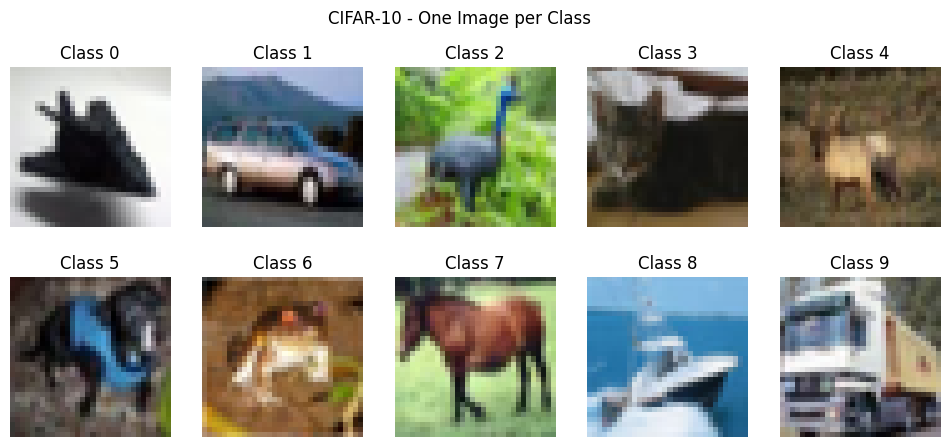

In [37]:
num_classes_cifar = len(np.unique(y_train_cifar))
print(f"CIFAR-10 Number of Classes: {num_classes_cifar}")

# Image dimensions
img_shape_cifar = x_train_cifar.shape[1:]  # (32, 32, 3)
print(f"CIFAR-10 Image Shape: {img_shape_cifar}")

# Display one image from each class
plt.figure(figsize=(12, 5))
for i in range(num_classes_cifar):
    idx = np.where(y_train_cifar.flatten() == i)[0][0]  # first index of class i
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train_cifar[idx])
    plt.title(f"Class {i}")
    plt.axis('off')
plt.suptitle("CIFAR-10 - One Image per Class")
plt.show()

## 2) Preprocess the dataset

In [38]:
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

y_train_cifar_cat = to_categorical(y_train_cifar, num_classes_cifar)
y_test_cifar_cat = to_categorical(y_test_cifar, num_classes_cifar)

## 3) Define the FCNN Model

In [39]:
model_fcnn_cifar = Sequential()
model_fcnn_cifar.add(Flatten(input_shape=img_shape_cifar))
model_fcnn_cifar.add(Dense(512, activation='relu'))
model_fcnn_cifar.add(Dense(256, activation='relu'))
model_fcnn_cifar.add(Dense(num_classes_cifar, activation='softmax'))

model_fcnn_cifar.summary()

/home/student/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## 4) Compile the FCNN Model

In [40]:
model_fcnn_cifar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 5) Train the FCNN Model

In [41]:
history_fcnn_cifar = model_fcnn_cifar.fit(
    x_train_cifar, y_train_cifar_cat,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=2
)

Epoch 1/30


2025-08-07 12:04:09.341588: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_162', 8 bytes spill stores, 8 bytes spill loads

2025-08-07 12:04:09.367622: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_162', 484 bytes spill stores, 484 bytes spill loads

2025-08-07 12:04:09.816372: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_162_0', 348 bytes spill stores, 348 bytes spill loads

2025-08-07 12:04:10.713675: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 4 bytes spill stores, 4 bytes spill loads

2025-08-07 12:04:11.057371: I external/loc

704/704 - 20s - 28ms/step - accuracy: 0.3231 - loss: 1.8856 - val_accuracy: 0.3660 - val_loss: 1.7595
Epoch 2/30
704/704 - 3s - 5ms/step - accuracy: 0.3973 - loss: 1.6884 - val_accuracy: 0.3882 - val_loss: 1.7229
Epoch 3/30
704/704 - 3s - 5ms/step - accuracy: 0.4263 - loss: 1.6025 - val_accuracy: 0.4248 - val_loss: 1.6160
Epoch 4/30
704/704 - 3s - 5ms/step - accuracy: 0.4476 - loss: 1.5437 - val_accuracy: 0.4308 - val_loss: 1.5811
Epoch 5/30
704/704 - 3s - 5ms/step - accuracy: 0.4640 - loss: 1.5064 - val_accuracy: 0.4666 - val_loss: 1.5158
Epoch 6/30
704/704 - 3s - 5ms/step - accuracy: 0.4744 - loss: 1.4717 - val_accuracy: 0.4688 - val_loss: 1.5085
Epoch 7/30
704/704 - 3s - 5ms/step - accuracy: 0.4880 - loss: 1.4380 - val_accuracy: 0.4484 - val_loss: 1.5541
Epoch 8/30
704/704 - 3s - 5ms/step - accuracy: 0.4973 - loss: 1.4123 - val_accuracy: 0.4736 - val_loss: 1.4890
Epoch 9/30
704/704 - 3s - 5ms/step - accuracy: 0.5055 - loss: 1.3872 - val_accuracy: 0.4888 - val_loss: 1.4523
Epoch 10/3

## 6) Evaluate the FCNN Model

2025-08-07 12:06:02.593934: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_62', 484 bytes spill stores, 484 bytes spill loads

2025-08-07 12:06:02.598597: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_62_0', 44 bytes spill stores, 44 bytes spill loads

2025-08-07 12:06:02.832605: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_69', 4 bytes spill stores, 4 bytes spill loads

2025-08-07 12:06:07.960812: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_62', 52 bytes spill stores, 52 bytes spill loads



CIFAR-10 FCNN Test Accuracy: 0.5087


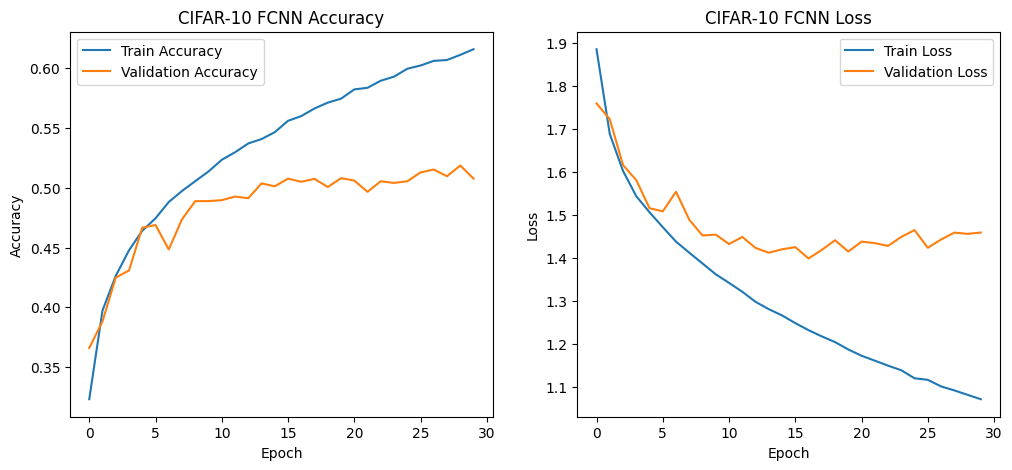

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Classification Report for FCNN (CIFAR-10):
              precision    recall  f1-score   support

           0       0.63      0.47      0.54      1000
           1       0.64      0.64      0.64      1000
           2       0.45      0.32      0.37      1000
           3       0.35      0.31      0.33      1000
           4       0.49      0.38      0.43      1000
           5       0.39      0.49      0.43      1000
           6       0.47      0.68      0.55      1000
           7       0.57      0.54      0.56      1000
           8       0.56      0.72      0.63      1000
           9       0.57      0.54      0.55      1000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



In [42]:
loss_fcnn_cifar, acc_fcnn_cifar = model_fcnn_cifar.evaluate(x_test_cifar, y_test_cifar_cat, verbose=0)
print(f"CIFAR-10 FCNN Test Accuracy: {acc_fcnn_cifar:.4f}")

# Plot accuracy and loss curves for FCNN CIFAR-10
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_fcnn_cifar.history['accuracy'], label='Train Accuracy')
plt.plot(history_fcnn_cifar.history['val_accuracy'], label='Validation Accuracy')
plt.title('CIFAR-10 FCNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_fcnn_cifar.history['loss'], label='Train Loss')
plt.plot(history_fcnn_cifar.history['val_loss'], label='Validation Loss')
plt.title('CIFAR-10 FCNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Classification report for FCNN CIFAR-10
y_pred_fcnn_cifar = model_fcnn_cifar.predict(x_test_cifar)
y_pred_labels_fcnn_cifar = np.argmax(y_pred_fcnn_cifar, axis=1)
print("Classification Report for FCNN (CIFAR-10):")
print(classification_report(y_test_cifar, y_pred_labels_fcnn_cifar))

## 7) Define the first CNN Model

In [43]:
model_cnn1_cifar = Sequential()
model_cnn1_cifar.add(Conv2D(32, kernel_size=(5,5), strides=1, padding='valid', activation='relu', input_shape=img_shape_cifar))
model_cnn1_cifar.add(MaxPooling2D(pool_size=(2,2), strides=2))
model_cnn1_cifar.add(Flatten())
model_cnn1_cifar.add(Dense(100, activation='relu'))
model_cnn1_cifar.add(Dense(num_classes_cifar, activation='softmax'))

model_cnn1_cifar.summary()

/home/student/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │       627,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 630,742 (2.41 MB)

 Trainable params: 630,742 (2.41 MB)

 Non-trainable params: 0 (0.00 B)

## 8) Compile the first CNN Model

In [44]:
model_cnn1_cifar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 9) Train the first CNN Model

In [45]:
history_cnn1_cifar = model_cnn1_cifar.fit(
    x_train_cifar, y_train_cifar_cat,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=2
)

Epoch 1/30
704/704 - 10s - 14ms/step - accuracy: 0.4577 - loss: 1.5198 - val_accuracy: 0.5402 - val_loss: 1.3180
Epoch 2/30
704/704 - 3s - 5ms/step - accuracy: 0.5698 - loss: 1.2186 - val_accuracy: 0.5760 - val_loss: 1.2003
Epoch 3/30
704/704 - 3s - 5ms/step - accuracy: 0.6242 - loss: 1.0713 - val_accuracy: 0.6380 - val_loss: 1.0706
Epoch 4/30
704/704 - 3s - 5ms/step - accuracy: 0.6635 - loss: 0.9683 - val_accuracy: 0.6374 - val_loss: 1.0671
Epoch 5/30
704/704 - 3s - 5ms/step - accuracy: 0.6859 - loss: 0.8979 - val_accuracy: 0.6618 - val_loss: 1.0135
Epoch 6/30
704/704 - 3s - 5ms/step - accuracy: 0.7113 - loss: 0.8250 - val_accuracy: 0.6648 - val_loss: 0.9981
Epoch 7/30
704/704 - 3s - 5ms/step - accuracy: 0.7291 - loss: 0.7732 - val_accuracy: 0.6502 - val_loss: 1.0681
Epoch 8/30
704/704 - 3s - 5ms/step - accuracy: 0.7502 - loss: 0.7166 - val_accuracy: 0.6408 - val_loss: 1.0848
Epoch 9/30
704/704 - 3s - 5ms/step - accuracy: 0.7686 - loss: 0.6652 - val_accuracy: 0.6562 - val_loss: 1.0745

## 10) Evaluate the first CNN Model

CIFAR-10 CNN-1 Test Accuracy: 0.6062


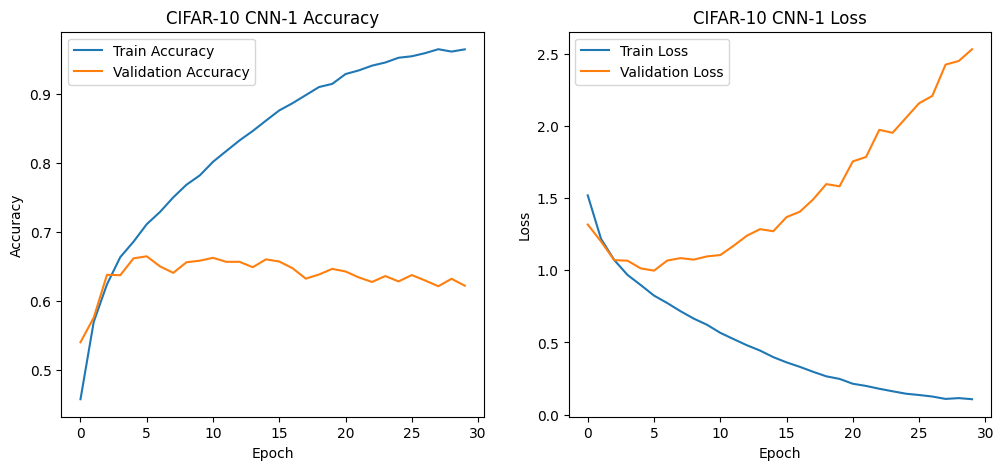

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report for CNN-1 (CIFAR-10):
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      1000
           1       0.66      0.75      0.70      1000
           2       0.50      0.43      0.46      1000
           3       0.45      0.34      0.39      1000
           4       0.51      0.61      0.56      1000
           5       0.52      0.47      0.49      1000
           6       0.71      0.68      0.69      1000
           7       0.64      0.70      0.67      1000
           8       0.72      0.74      0.73      1000
           9       0.65      0.71      0.68      1000

    accuracy                           0.61     10000
   macro avg       0.60      0.61      0.60     10000
weighted avg       0.60      0.61      0.60     10000



In [46]:
loss_cnn1_cifar, acc_cnn1_cifar = model_cnn1_cifar.evaluate(x_test_cifar, y_test_cifar_cat, verbose=0)
print(f"CIFAR-10 CNN-1 Test Accuracy: {acc_cnn1_cifar:.4f}")

# Plot accuracy and loss for CIFAR-10 CNN-1
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_cnn1_cifar.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn1_cifar.history['val_accuracy'], label='Validation Accuracy')
plt.title('CIFAR-10 CNN-1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn1_cifar.history['loss'], label='Train Loss')
plt.plot(history_cnn1_cifar.history['val_loss'], label='Validation Loss')
plt.title('CIFAR-10 CNN-1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Classification report for CIFAR-10 CNN-1
y_pred_cnn1_cifar = model_cnn1_cifar.predict(x_test_cifar)
y_pred_labels_cnn1_cifar = np.argmax(y_pred_cnn1_cifar, axis=1)
print("Classification Report for CNN-1 (CIFAR-10):")
print(classification_report(y_test_cifar, y_pred_labels_cnn1_cifar))

## 11) Define the second CNN Model

In [47]:
model_cnn2_cifar = Sequential()
model_cnn2_cifar.add(Conv2D(32, kernel_size=(3,3), strides=1, padding='valid', activation='relu', input_shape=img_shape_cifar))
model_cnn2_cifar.add(Conv2D(32, kernel_size=(3,3), strides=1, padding='valid', activation='relu'))
model_cnn2_cifar.add(MaxPooling2D(pool_size=(2,2), strides=2))
model_cnn2_cifar.add(Flatten())
model_cnn2_cifar.add(Dense(100, activation='relu'))
model_cnn2_cifar.add(Dense(num_classes_cifar, activation='softmax'))

model_cnn2_cifar.summary()

/home/student/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │       627,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 638,454 (2.44 MB)

 Trainable params: 638,454 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

## 12) Compile the second CNN Model

In [48]:
model_cnn2_cifar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 13) Train the second CNN Model

In [49]:
history_cnn2_cifar = model_cnn2_cifar.fit(
    x_train_cifar, y_train_cifar_cat,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=2
)

Epoch 1/30
704/704 - 11s - 16ms/step - accuracy: 0.4795 - loss: 1.4460 - val_accuracy: 0.5758 - val_loss: 1.2337
Epoch 2/30
704/704 - 4s - 5ms/step - accuracy: 0.6243 - loss: 1.0729 - val_accuracy: 0.6294 - val_loss: 1.0765
Epoch 3/30
704/704 - 4s - 5ms/step - accuracy: 0.6743 - loss: 0.9326 - val_accuracy: 0.6638 - val_loss: 0.9784
Epoch 4/30
704/704 - 4s - 5ms/step - accuracy: 0.7074 - loss: 0.8352 - val_accuracy: 0.6770 - val_loss: 0.9443
Epoch 5/30
704/704 - 4s - 5ms/step - accuracy: 0.7401 - loss: 0.7469 - val_accuracy: 0.6834 - val_loss: 0.9344
Epoch 6/30
704/704 - 4s - 5ms/step - accuracy: 0.7676 - loss: 0.6649 - val_accuracy: 0.6900 - val_loss: 0.9419
Epoch 7/30
704/704 - 4s - 5ms/step - accuracy: 0.7959 - loss: 0.5907 - val_accuracy: 0.6854 - val_loss: 0.9739
Epoch 8/30
704/704 - 4s - 5ms/step - accuracy: 0.8189 - loss: 0.5181 - val_accuracy: 0.6860 - val_loss: 1.0141
Epoch 9/30
704/704 - 4s - 5ms/step - accuracy: 0.8481 - loss: 0.4406 - val_accuracy: 0.6878 - val_loss: 1.0403

## 14) Evaluate the second CNN Model

CIFAR-10 CNN-2 Test Accuracy: 0.6474


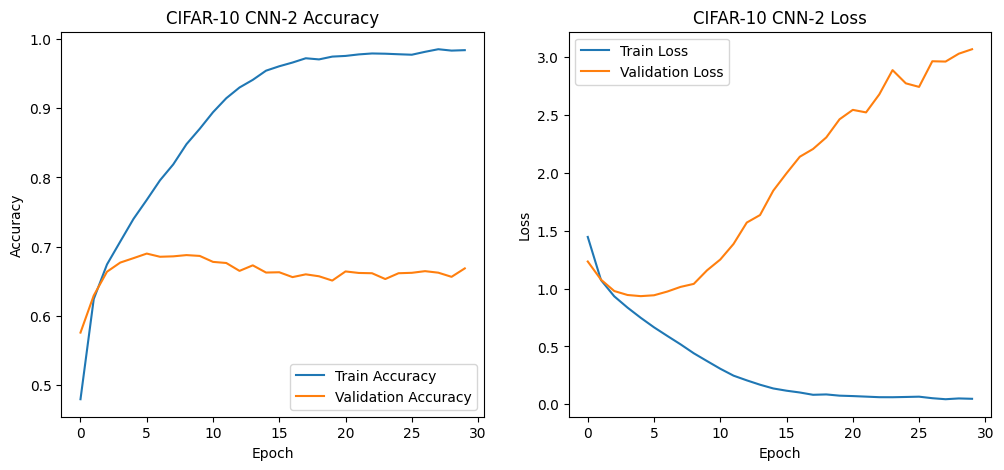

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report for CNN-2 (CIFAR-10):
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      1000
           1       0.79      0.76      0.77      1000
           2       0.52      0.49      0.51      1000
           3       0.42      0.48      0.45      1000
           4       0.63      0.55      0.59      1000
           5       0.49      0.58      0.53      1000
           6       0.73      0.70      0.71      1000
           7       0.74      0.68      0.71      1000
           8       0.79      0.76      0.77      1000
           9       0.74      0.77      0.75      1000

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.65     10000
weighted avg       0.65      0.65      0.65     10000



In [50]:
loss_cnn2_cifar, acc_cnn2_cifar = model_cnn2_cifar.evaluate(x_test_cifar, y_test_cifar_cat, verbose=0)
print(f"CIFAR-10 CNN-2 Test Accuracy: {acc_cnn2_cifar:.4f}")

# Plot accuracy and loss for CIFAR-10 CNN-2
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_cnn2_cifar.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn2_cifar.history['val_accuracy'], label='Validation Accuracy')
plt.title('CIFAR-10 CNN-2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn2_cifar.history['loss'], label='Train Loss')
plt.plot(history_cnn2_cifar.history['val_loss'], label='Validation Loss')
plt.title('CIFAR-10 CNN-2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Classification report for CIFAR-10 CNN-2
y_pred_cnn2_cifar = model_cnn2_cifar.predict(x_test_cifar)
y_pred_labels_cnn2_cifar = np.argmax(y_pred_cnn2_cifar, axis=1)
print("Classification Report for CNN-2 (CIFAR-10):")
print(classification_report(y_test_cifar, y_pred_labels_cnn2_cifar))

# Insights (Q4 and Q5)

## Q4. Comparison of Performances of FCNN and CNN

Convolutional Neural Networks (CNNs) generally outperform Fully Connected Neural Networks (FCNNs) on image datasets, like the given Fashion MNIST and CIFAR-10 datasets for several important reasons:

- **Local Connectivity and Spatial Hierarchy:** CNNs leverage the convolution operation to exploit the spatial structure of images. Instead of treating each pixel independently, convolutions capture local patterns such as edges, textures, and shapes by using small receptive fields (kernels). This enables the network to build hierarchical feature representations, which are critical for understanding images.

- **Parameter Efficiency:** CNNs share weights across the image through convolutional kernels, drastically reducing the number of parameters compared to FCNNs that connect every input pixel to every neuron. This reduces overfitting and improves generalization on image data.

- **Handling Extra Dimensions:** CNNs naturally handle multi-channel inputs (e.g., RGB images) by applying filters across all channels simultaneously, preserving the 3D structure (height, width, channels) of the data. FCNNs, on the other hand, require flattening images into 1D vectors, losing spatial and channel-wise relationships.

Between the two CNN architectures given:

- **CNN-2** (with two consecutive convolutional layers) performs better than **CNN-1** because stacking convolutional layers allows the model to learn more complex and abstract features. The first convolution layer might detect simple edges or textures, while the second can combine those to identify higher-level patterns. This deeper feature extraction generally improves classification accuracy, especially on complex datasets.

---

## Q5. Comparison of Number of Parameters in FCNN and CNN and Main Contributors in CNN

- **Parameter Count Difference:** FCNNs typically have far more parameters than CNNs because they fully connect every input pixel (after flattening) to each neuron in the first hidden layer. For example, flattening a 28x28 grayscale image results in 784 input neurons, which fully connected to 100 neurons means 78,400 weights just in one layer, not counting biases. In contrast, CNNs use small kernels with shared weights, greatly reducing parameters.

- **Main Contributors of Parameters in CNN:**  
  - The **fully connected (dense) layers** at the end of the CNN often contain the largest number of parameters because they connect the flattened output of the convolution/pooling layers to the final classification neurons.  
  - Among convolutional layers, layers with **larger kernel sizes and more filters** contribute more parameters. For example, a convolutional layer with 32 kernels of size 5x5 has more parameters than one with 32 kernels of size 3x3 (since each kernel has more weights).  
  - Also, the **number of filters (channels)** directly scales the number of parameters in convolutional layers because each filter has its own set of weights.

In summary, CNNs achieve parameter efficiency by sharing weights in convolution layers but still accumulate most parameters in their dense classification layers. FCNNs lack this efficiency, making CNNs better suited for image tasks both in performance and model size.

